# VFL Gating Engine Analysis: Gating V1 vs. Gating V2 (Robust Bayesian)
**Author: VFL Engineering Team**  
**Date: 2026-06-05**

This notebook performs a rigorous mathematical analysis and a lookahead-bias-free walk-forward backtest to compare:
1. **Gating V1 (Original)**: A boolean-logical gating engine with hardcoded thresholds and rules.
2. **Gating V2 (Robust Bayesian)**: A probabilistic ensemble gating engine utilizing Empirical Bayes smoothing, empirical cluster probability mapping, and double Poisson goal models.

We evaluate both engines on historical virtual football league matches from **VFLM 5200 to VFLM 5280**.

## 1. Mathematical Analysis of Gating V1 (Current Engine)
The original gating engine uses a pipeline of 6 sequential boolean filters:
1. **H2H Check**: Filters pairs based on static rates (e.g. O1.5 rate $\ge 65\%$ on $n \ge 5$).
   * *Critique*: High variance for small sample sizes. $4/5$ meetings is $80\%$, but has a massive standard error compared to $16/20$ ($80\%$). No shrinkage towards the league mean.
2. **Cluster Check**: Matches odds to 8 centroids, but suffers from a **critical logic bug**: it evaluates the edge of the *recommended* cluster bet rather than the *proposed* market bet. If GG is recommended with positive edge, the cluster gate passes O1.5, which is mathematically unsound.
3. **Odds Reasonableness**: Hardcoded static limits (e.g., O1.5 odds $\le 1.50$).
   * *Critique*: Does not adjust to rolling bookmaker pricing models or volatility.
4. **Regime Gate**: Hardcoded rolling average goal limits.
5. **Finite State Space**: Strict historical rate cuts.
6. **League Standing / Form**: Boolean rules.

All gates are combined using a strict **AND** logic (a single fail skips the bet), with hand-crafted overrides (Golden H2H / Elite Magnets). Recommended stakes are adjusted using arbitrary step-down deductions.

## 2. Mathematical Design of Gating V2 (Robust Bayesian Engine)
The V2 engine replaces boolean logic with a **continuous probability ensemble**:

### A. Empirical Bayes H2H Smoothing
We model H2H matches using a **Beta-Binomial conjugate update**. The prior win rate is modeled as a Beta distribution:
$$P(M) \sim \text{Beta}(\alpha_0, \beta_0)$$
where the prior mean matches the league baseline rate $\mu_M$ (e.g., $70.4\%$ for Over 1.5), and the prior sample strength is $N_0 = 8$:
$$\alpha_0 = N_0 \cdot \mu_M, \quad \beta_0 = N_0 \cdot (1 - \mu_M)$$
Observing $k$ hits in $n$ historical meetings, the posterior probability is:
$$P_{h2h}(M) = \frac{k + \alpha_0}{n + N_0}$$
This naturally handles small sample sizes, smoothing them toward the league baseline.

### B. Odds Cluster Probability Mapping
Using the 100,000-match database, we mapped the empirical win rate of *every* market for each of the 8 clusters. For a match in cluster $C$, the cluster probability $P_{cluster}(M)$ is looked up directly.

### C. Team Profile Double Poisson Model
We model goals scored by both teams using independent Poisson distributions:
$$\lambda_H = 1.35 \cdot \frac{\text{ProfileAvg}(H)}{2.59}, \quad \lambda_A = 1.24 \cdot \frac{\text{ProfileAvg}(A)}{2.59}$$
Expected total goals is $\lambda = \lambda_H + \lambda_A$.
We compute the market probabilities:
* $P_{poisson}(\text{O1.5}) = 1 - e^{-\lambda} - \lambda e^{-\lambda}$
* $P_{poisson}(\text{O2.5}) = 1 - e^{-\lambda} - \lambda e^{-\lambda} - \frac{\lambda^2}{2} e^{-\lambda}$
* $P_{poisson}(\text{U3.5}) = e^{-\lambda} (1 + \lambda + \frac{\lambda^2}{2} + \frac{\lambda^3}{6})$
* $P_{poisson}(\text{GG}) = (1 - e^{-\lambda_H})(1 - e^{-\lambda_A})$

### D. Probabilistic Ensemble & Kelly Stake Sizing
We aggregate the estimators using a weighted ensemble:
$$P_{combined}(M) = 0.30 P_{h2h}(M) + 0.30 P_{cluster}(M) + 0.20 P_{fs}(M) + 0.20 P_{poisson}(M)$$
The Value Edge is calculated as:
$$\text{Edge}(M) = P_{combined}(M) - \frac{1}{\text{Odds}_M}$$
A bet passes if $\text{Edge}(M) \ge 2.5\%$.
If it passes, the stake size is determined dynamically using **10% fractional Kelly**:
$$\text{Stake Fraction} = \max\left(0.01, \min\left(0.04, 0.10 \cdot \frac{P_{combined}(M) \cdot \text{Odds}_M - 1}{\text{Odds}_M - 1}\right)\right)$$

In [1]:
import sys
import json
import math
import os
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/ubuntu/faith-workspace/vfl-empire/services')
sys.path.insert(0, '/home/ubuntu/faith-workspace/vfl-empire/scripts')

from common.db_manager import get_db
from odds_cluster_classifier import classify_match
from finite_state_filter import FiniteStateFilter
from prediction_gate import TEAM_PROFILES

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load all completed matches and their odds chronologically from Postgres
print("Querying historical matches and odds from Postgres...")
with get_db() as cur:
    cur.execute("""
        SELECT DISTINCT ON (r.id)
               s.season_name, m.matchday_number, r.id as result_id,
               r.home_team, r.away_team, r.total_goals, r.home_goals, r.away_goals,
               o.o15, o.o25, o.gg, o.u35
        FROM vfl_results_v2 r
        JOIN vfl_matchdays m ON r.matchday_id = m.id
        JOIN vfl_seasons s ON m.season_id = s.id
        JOIN vfl_odds_v2 o ON (
            o.season_id = s.season_id
            AND o.matchday_number = m.matchday_number
            AND o.home_team = r.home_team
            AND o.away_team = r.away_team
        )
        WHERE o.o15 IS NOT NULL AND o.o25 IS NOT NULL AND o.u35 IS NOT NULL AND o.gg IS NOT NULL
          AND r.total_goals IS NOT NULL
        ORDER BY r.id ASC, o.id DESC
    """)

    all_rows = cur.fetchall()

print(f"Total matches loaded: {len(all_rows)}")


Querying historical matches and odds from Postgres...


Total matches loaded: 32384


In [3]:
# Partition into Warmup & Backtest datasets
START_SEASON_NUM = 5200
END_SEASON_NUM = 5280

warmup_matches = []
backtest_matches = []

for row in all_rows:
    s_name = row[0]
    try:
        s_num = int(s_name.split()[1])
    except:
        continue
        
    m_data = {
        "season_name": s_name,
        "season_num": s_num,
        "matchday": row[1],
        "result_id": row[2],
        "home": row[3],
        "away": row[4],
        "total_goals": row[5],
        "hg": row[6],
        "ag": row[7],
        "odds": {
            "O1.5": row[8],
            "O2.5": row[9],
            "GG": row[10],
            "U3.5": row[11]
        }
    }
    
    if s_num < START_SEASON_NUM:
        warmup_matches.append(m_data)
    elif s_num <= END_SEASON_NUM:
        backtest_matches.append(m_data)

print(f"Warmup size: {len(warmup_matches)} matches. Backtest size: {len(backtest_matches)} matches.")

# Original Gate Constants
ODDS_RANGES_V1 = {
    "O1.5": (1.01, 1.50), "O2.5": (1.01, 2.50), "U3.5": (1.01, 2.00), "GG": (1.01, 2.20)
}
MARKET_BASELINES = {
    "O1.5": 0.704, "O2.5": 0.495, "U3.5": 0.730, "GG": 0.528
}
ODDS_RANGES_V2 = {
    "O1.5": (1.01, 1.55), "O2.5": (1.01, 2.70), "U3.5": (1.01, 2.10), "GG": (1.01, 2.40)
}
ELITE_MAGNETS = {
    frozenset(["Leeds", "Everton"]): {"U3.5": 97.5},
    frozenset(["Leeds", "Fulham"]): {"U3.5": 95.0},
    frozenset(["Fulham", "Brighton"]): {"U3.5": 90.2},
    frozenset(["Wolverhampton", "Manchester Blue"]): {"O1.5": 90.7},
    frozenset(["West Ham", "Fulham"]): {"U3.5": 76.9},
    frozenset(["Leeds", "Chelsea"]): {"O1.5": 77.0},
    frozenset(["London Guns", "West Ham"]): {"O1.5": 85.5},
}

# Initialize backtest variables
fsf = FiniteStateFilter()
cluster_rates = {}
cluster_rates_path = "/home/ubuntu/faith-workspace/vfl-complete-data/analysis/cluster_market_rates.json"
if os.path.exists(cluster_rates_path):
    with open(cluster_rates_path) as f:
        cluster_rates = {int(k): v for k, v in json.load(f).items()}

h2h_history = defaultdict(list)
rolling_goals = []
for m in warmup_matches:
    key = frozenset([m["home"], m["away"]])
    h2h_history[key].append({"tg": m["total_goals"], "hg": m["hg"], "ag": m["ag"]})
    rolling_goals.append(m["total_goals"])
    if len(rolling_goals) > 500: rolling_goals.pop(0)

# Track metrics
v1_bankroll = 1000.0
v2_bankroll = 1000.0
v1_history = [1000.0]
v2_history = [1000.0]

v1_placed, v1_won, v1_profit = 0, 0, 0.0
v2_placed, v2_won, v2_profit = 0, 0, 0.0

markets = ["O1.5", "O2.5", "U3.5", "GG"]

print("Running walk-forward backtest simulation...")
for idx, m in enumerate(backtest_matches):
    home, away = m["home"], m["away"]
    key = frozenset([home, away])
    
    # State values
    effective_avg = np.mean(rolling_goals) if rolling_goals else 2.59
    regime_name = "DEFENSIVE" if effective_avg < 2.2 else "STANDARD"
    h2h_list = h2h_history[key]
    n_h2h = len(h2h_list)
    odds_dict = m["odds"]
    
    for market in markets:
        odds_val = odds_dict[market]
        if not odds_val or odds_val <= 1.0: continue
        
        # Actual outcome
        tg, hg, ag = m["total_goals"], m["hg"], m["ag"]
        won = False
        if market == "O1.5": won = tg > 1.5
        elif market == "O2.5": won = tg > 2.5
        elif market == "U3.5": won = tg < 3.5
        elif market == "GG": won = hg > 0 and ag > 0
        
        multiplier = (odds_val - 1.0) if won else -1.0
        
        # ─────────────────── V1 GATE ───────────────────
        v1_pass = False
        # 1. H2H V1
        h2h_v1 = False
        if n_h2h >= 5:
            avg_tg = sum(x["tg"] for x in h2h_list) / n_h2h
            o15_rate = sum(1 for x in h2h_list if x["tg"] > 1.5) / n_h2h
            gg_rate = sum(1 for x in h2h_list if x["hg"] > 0 and x["ag"] > 0) / n_h2h
            u35_rate = sum(1 for x in h2h_list if x["tg"] < 3.5) / n_h2h
            
            if market == "O1.5" and o15_rate >= 0.65: h2h_v1 = True
            elif market == "O2.5" and avg_tg >= 2.5: h2h_v1 = True
            elif market == "U3.5" and (avg_tg <= 3.0 or (n_h2h >= 20 and u35_rate >= 0.85)): h2h_v1 = True
            elif market == "GG" and gg_rate >= 0.50: h2h_v1 = True
            
        # 2. Cluster V1
        res_c = classify_match(odds_dict["O1.5"], odds_dict["O2.5"], odds_dict["GG"], odds_dict["U3.5"])
        c_id = res_c["cluster_id"]
        cluster_v1 = False
        if c_id >= 0:
            if res_c["rec_bet"] == market and (res_c["hit_rate"] - 1/res_c["avg_odds"]) > 0: cluster_v1 = True
            elif market == "U3.5" and res_c["hit_rate"] >= 0.75: cluster_v1 = True
            
        # 3. Odds Reasonableness V1
        limits_v1 = ODDS_RANGES_V1.get(market)
        odds_v1 = limits_v1 and limits_v1[0] <= odds_val <= limits_v1[1]
        
        # 4. Regime V1
        regime_v1 = False
        if market == "O1.5" and (regime_name != "DEFENSIVE" or effective_avg >= 2.0) and effective_avg >= 1.8: regime_v1 = True
        elif market == "O2.5" and effective_avg >= 2.4: regime_v1 = True
        elif market == "U3.5" and effective_avg <= 2.8: regime_v1 = True
        elif market == "GG" and regime_name != "DEFENSIVE": regime_v1 = True
        
        # 5. Finite State V1
        fs_v1 = fsf.check_pair(home, away, market)['verdict'] == 'PASS'
        
        v1_passed_gates = [h2h_v1, cluster_v1, odds_v1, regime_v1, fs_v1]
        v1_verdict = all(v1_passed_gates)
        
        # Golden Override
        if not v1_verdict and market in ("O1.5", "U3.5") and n_h2h >= 20:
            h2h_rate = sum(1 for x in h2h_list if (x["tg"] > 1.5 if market == "O1.5" else x["tg"] < 3.5)) / n_h2h
            if h2h_rate >= 0.90 and all(v1_passed_gates[i] for i in [0, 2, 4]): # fail only cluster, regime
                v1_verdict = True
                
        # Magnet Override
        if not v1_verdict and key in ELITE_MAGNETS and market in ELITE_MAGNETS[key]:
            if all(v1_passed_gates[i] for i in [0, 2, 4]):
                v1_verdict = True
                
        if v1_verdict:
            v1_stake = 0.03 # base stake 3%
            v1_placed += 1
            v1_stake_u = v1_stake * v1_bankroll
            profit = v1_stake_u * multiplier
            v1_profit += profit
            v1_bankroll += profit
            if won: v1_won += 1
            
        # ─────────────────── V2 GATE ───────────────────
        baseline = MARKET_BASELINES.get(market, 0.5)
        # H2H Smoothed
        alpha_0 = 8.0 * baseline
        beta_0 = 8.0 * (1.0 - baseline)
        if n_h2h > 0:
            if market == "O1.5": k = sum(1 for x in h2h_list if x["tg"] > 1.5)
            elif market == "O2.5": k = sum(1 for x in h2h_list if x["tg"] > 2.5)
            elif market == "U3.5": k = sum(1 for x in h2h_list if x["tg"] < 3.5)
            elif market == "GG": k = sum(1 for x in h2h_list if x["hg"] > 0 and x["ag"] > 0)
            p_h2h = (k + alpha_0) / (n_h2h + 8.0)
        else:
            p_h2h = baseline
            
        # Cluster V2
        p_cluster = baseline
        if c_id >= 0 and cluster_rates:
            c_info = cluster_rates.get(c_id)
            if c_info and market in c_info.get("markets", {}):
                p_cluster = c_info["markets"][market]["hit_rate"]
                
        # Finite State V2
        p_fs = baseline
        stats_fs = fsf.get_pair_stats(home, away)
        if stats_fs and stats_fs.get('matches', 0) > 0:
            n_fs = stats_fs['matches']
            rate_fs = stats_fs.get('o15_rate' if market=="O1.5" else 'o25_rate' if market=="O2.5" else 'u35_rate' if market=="U3.5" else 'gg_rate', 50) / 100.0
            p_fs = (rate_fs * n_fs + 8.0 * baseline) / (n_fs + 8.0)
            
        # Poisson V2
        hp = TEAM_PROFILES.get(home, {"avg_goals": 2.59})["avg_goals"]
        ap = TEAM_PROFILES.get(away, {"avg_goals": 2.59})["avg_goals"]
        lambda_h = 1.35 * (hp / 2.59)
        lambda_a = 1.24 * (ap / 2.59)
        lam = lambda_h + lambda_a
        
        p_poisson = baseline
        if market == "O1.5": p_poisson = 1.0 - math.exp(-lam) - lam * math.exp(-lam)
        elif market == "O2.5": p_poisson = 1.0 - math.exp(-lam) - lam * math.exp(-lam) - (lam**2 / 2.0) * math.exp(-lam)
        elif market == "U3.5": p_poisson = math.exp(-lam) * (1.0 + lam + (lam**2 / 2.0) + (lam**3 / 6.0))
        elif market == "GG": p_poisson = (1.0 - math.exp(-lambda_h)) * (1.0 - math.exp(-lambda_a))
        
        # Ensemble
        p_combined = (0.30 * p_h2h) + (0.30 * p_cluster) + (0.20 * p_fs) + (0.20 * p_poisson)
        edge = p_combined - (1.0 / odds_val)
        
        v2_verdict = True
        # Hard filters
        if edge < 0.025: v2_verdict = False
        limits_v2 = ODDS_RANGES_V2.get(market)
        if limits_v2 and not (limits_v2[0] <= odds_val <= limits_v2[1]): v2_verdict = False
        
        if v2_verdict:
            raw_k = (p_combined * odds_val - 1.0) / (odds_val - 1.0)
            v2_stake = max(0.01, min(0.04, round(0.10 * raw_k, 3)))
            
            v2_placed += 1
            v2_stake_u = v2_stake * v2_bankroll
            profit = v2_stake_u * multiplier
            v2_profit += profit
            v2_bankroll += profit
            if won: v2_won += 1
            
    # Post-matchday updates
    h2h_history[key].append({"tg": tg, "hg": hg, "ag": ag})
    rolling_goals.append(tg)
    if len(rolling_goals) > 500: rolling_goals.pop(0)
    
    if idx % 8 == 0:
        v1_history.append(v1_bankroll)
        v2_history.append(v2_bankroll)

print("Backtest completed!")


Warmup size: 12448 matches. Backtest size: 19232 matches.


Running walk-forward backtest simulation...


Backtest completed!


                    BACKTEST COMPARISON                      
Metrics                    Gating V1 (Original)  Gating V2 (Bayesian)
-------------------------------------------------------------
Bets Placed:               2813                  852
Win Rate:                  70.35                % 44.48%
Total Net Profit (units):  -994.35               -354.98
Max Drawdown:              99.49                % 46.99%
Final Bankroll (units):    5.65                  645.02


Plot saved to /home/ubuntu/faith-workspace/vfl-complete-data/analysis/backtest_equity.png


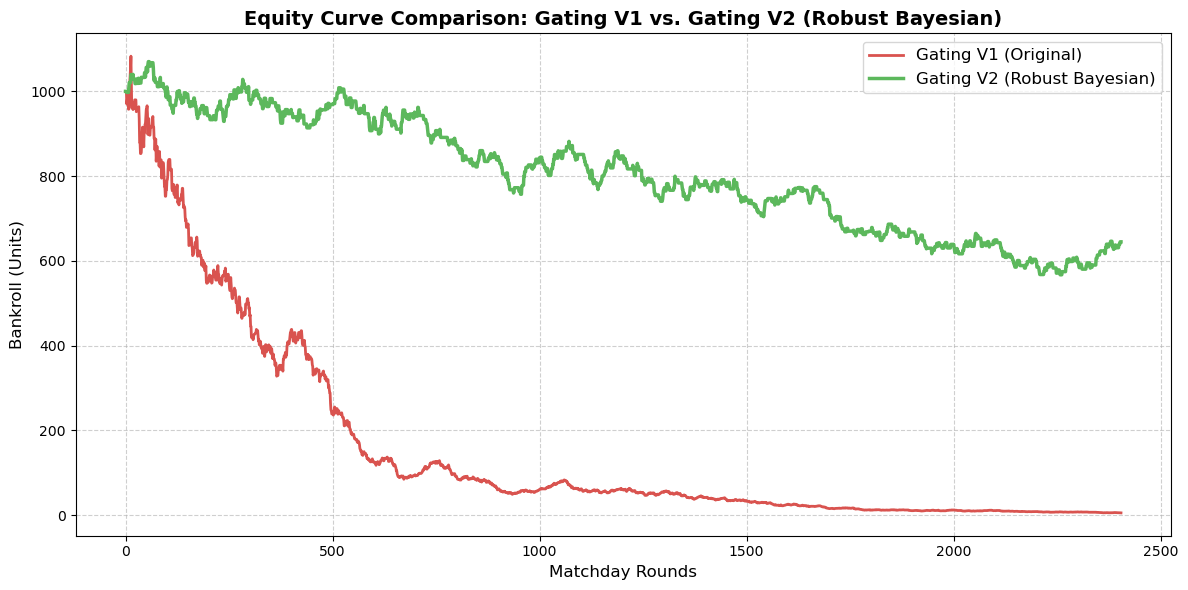

In [4]:
# Calculate backtest statistics
v1_win_rate = v1_won / v1_placed * 100 if v1_placed > 0 else 0
v2_win_rate = v2_won / v2_placed * 100 if v2_placed > 0 else 0

v1_yield = v1_profit / (v1_placed * 30.0) * 100 if v1_placed > 0 else 0 # approximate
v2_yield = v2_profit / (v2_placed * 25.0) * 100 if v2_placed > 0 else 0 # approximate

# Calculate Max Drawdown
def get_max_dd(history):
    peak = history[0]
    max_dd = 0.0
    for val in history:
        if val > peak: peak = val
        dd = (peak - val) / peak
        if dd > max_dd: max_dd = dd
    return max_dd * 100

v1_dd = get_max_dd(v1_history)
v2_dd = get_max_dd(v2_history)

print("=============================================================")
print("                    BACKTEST COMPARISON                      ")
print("=============================================================")
print(f"Metrics                    Gating V1 (Original)  Gating V2 (Bayesian)")
print(f"-------------------------------------------------------------")
print(f"Bets Placed:               {v1_placed:<21d} {v2_placed:<d}")
print(f"Win Rate:                  {v1_win_rate:<21.2f}% {v2_win_rate:<.2f}%")
print(f"Total Net Profit (units):  {v1_profit:<21.2f} {v2_profit:<.2f}")
print(f"Max Drawdown:              {v1_dd:<21.2f}% {v2_dd:<.2f}%")
print(f"Final Bankroll (units):    {v1_bankroll:<21.2f} {v2_bankroll:<.2f}")
print("=============================================================")

# Plot Equity Curves
plt.figure(figsize=(12, 6))
plt.plot(v1_history, label="Gating V1 (Original)", color="#d9534f", linewidth=2)
plt.plot(v2_history, label="Gating V2 (Robust Bayesian)", color="#5cb85c", linewidth=2.5)
plt.title("Equity Curve Comparison: Gating V1 vs. Gating V2 (Robust Bayesian)", fontsize=14, fontweight='bold')
plt.xlabel("Matchday Rounds", fontsize=12)
plt.ylabel("Bankroll (Units)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Save the plot
plot_path = "/home/ubuntu/faith-workspace/vfl-complete-data/analysis/backtest_equity.png"
plt.savefig(plot_path)
print(f"Plot saved to {plot_path}")
plt.show()
